In [3]:
import re 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# for text classification project sentiment analyisis
from sklearn.naive_bayes import MultinomialNB #ml model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix  
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS

In [4]:
df=pd.read_csv('Data/Data/movie_review.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
#clean text
def clean_text(text):
    # teo remove all unwanted HTML tags in review
    text = re.sub(r'<,*?>','',text)
    #remove all unwanted symbols , numbers and only keep text values only
    text=re.sub(r'[^a-zA-Z\s]','',text).lower()
    return  text


In [6]:
df['review']=df['review'].apply(clean_text)

In [7]:
X=df['review']
Y=df['sentiment']

In [8]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42

)

In [9]:
ignore_words={'no','not'}
custom_stop_words= list(set(('ENGLISH_STOP_WORDS')) - ignore_words)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# ensure stop words are built from the actual set, not string
ignore_words = {'no', 'not'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS) - ignore_words)

tfidf = TfidfVectorizer(stop_words=custom_stop_words, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
model = MultinomialNB(alpha=0.1)
model.fit(X_train_tfidf, Y_train)
Y_pred = model.predict(X_test_tfidf)
print(classification_report(Y_test, Y_pred))
print(confusion_matrix(Y_test, Y_pred))


              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      4961
    positive       0.90      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4463  498]
 [ 617 4422]]


<Axes: >

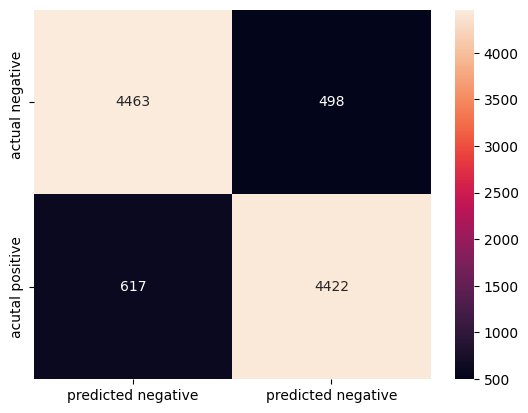

In [11]:
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True,fmt='.0f',xticklabels=['predicted negative','predicted negative'],yticklabels=['actual negative ','acutal positive'])